<a href="https://colab.research.google.com/github/LuCalderonS/Trabajo-pr-ctico-Python-Programaci-n-estad-stica-avanzada-UTDT-2026/blob/main/Trabajo_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Trabajo práctico Python-Programación Estadística Avanzada

---


#####El siguiente trabajo contiene la resolución de los ejercicios de las 3 partes determinadas en la consigna. A pesar de que puede ser ejecutado de una sola vez, es fundamental asegurar la ejecución de las dos primeras celdas de código Python. Estas contienen todas las librerías necesarias para la ejecución de gráficos, simulaciones, ect. y la semilla que fue utilizada para responder cada pregunta.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from math import sqrt
import statsmodels.api as sm
import seaborn as sns
from scipy.optimize import minimize

In [2]:
#Semilla con mis últimos 4 números de DNI (la usamos en otros trabajos de la
#Maestría)
np.random.seed(7109)

##Parte 1. Robustez ante la contaminación de muestras
#####A continuación se encuentran dos celdas de código, la primera para el inciso **1) Estimadores de tendencia central**; y el **2) Regresión lineal bajo contaminación**.

In [3]:
#1.1. ESTIMADORES DE TENDENCIA CENTRAL.
#Generación función para las muestras contaminadas
def muestra_contaminada (n,p,mu0,sigma0,mu1,sigma1):
  n_outliers=int(n*p)
  n_normales=int(n-n_outliers) #Hay que ponerlos como integer para que corra

  normales=np.random.normal(mu0,sigma0,n_normales)
  outliers=np.random.normal(mu1,sigma1,n_outliers)

  muestra=np.concatenate((normales,outliers))
  np.random.shuffle(muestra) #Para desordenar los datos de la muestra
  return muestra

#Sesgo y ECM
def calculo_sesgo(vector,valor_real):
  return np.mean(vector)-valor_real

def calculo_ecm(vector,valor_real):
  return np.mean((np.array(vector)-valor_real)**2)

#Parámetros de la simulación
M=1000
n=1000
mu0=0
sigma0=1
mu1=3
sigma1=sqrt(3)
porcentajes=[0,0.05,0.10,0.20]

resultados=[]

#Bucle
for p in porcentajes:
  medias=[]
  medianas=[]

  for _ in range(M):
    muestra=muestra_contaminada(n,p,mu0,sigma0,mu1,sigma1)
    medias.append(np.mean(muestra))
    medianas.append(np.median(muestra))


  resultados.append({
      "Contaminación": f"{int(p*100)}%",
      "p": p,
      "Sesgo media": calculo_sesgo(medias,mu0),
      "ECM media": calculo_ecm(medias,mu0),
      "Sesgo mediana": calculo_sesgo(medianas,mu0),
      "ECM mediana": calculo_ecm(medianas,mu0)
  })

df_resultados=pd.DataFrame(resultados)

print(f"{'Contaminación':<15} | {'Sesgo Media':<12} | {'ECM Media':<12} | {'Sesgo Mediana':<12} | {'ECM Mediana':<12}")
print("-" * 75)

for res in resultados:
    print(f"{res['Contaminación']:<15} | "
          f"{res['Sesgo media']:12.4f} | "
          f"{res['ECM media']:12.4f} | "
          f"{res['Sesgo mediana']:12.4f} | "
          f"{res['ECM mediana']:12.4f}")

#Punto de cruce
dif = df_resultados['ECM media'] - df_resultados['ECM mediana']
idx = np.where(dif > 0)[0][0] # Primer índice donde la media supera a la mediana
p_cruce = df_resultados['p'].iloc[idx-1] + (0 - dif.iloc[idx-1]) * \
          (df_resultados['p'].iloc[idx] - df_resultados['p'].iloc[idx-1]) / \
          (dif.iloc[idx] - dif.iloc[idx-1]) #Interpolación lineal
print(f"El punto de cruce es: {p_cruce: .2%} de contaminacion")

Contaminación   | Sesgo Media  | ECM Media    | Sesgo Mediana | ECM Mediana 
---------------------------------------------------------------------------
0%              |       0.0005 |       0.0010 |       0.0008 |       0.0015
5%              |       0.1481 |       0.0230 |       0.0586 |       0.0051
10%             |       0.3009 |       0.0917 |       0.1257 |       0.0175
20%             |       0.6008 |       0.3624 |       0.2808 |       0.0809
El punto de cruce es:  0.14% de contaminacion


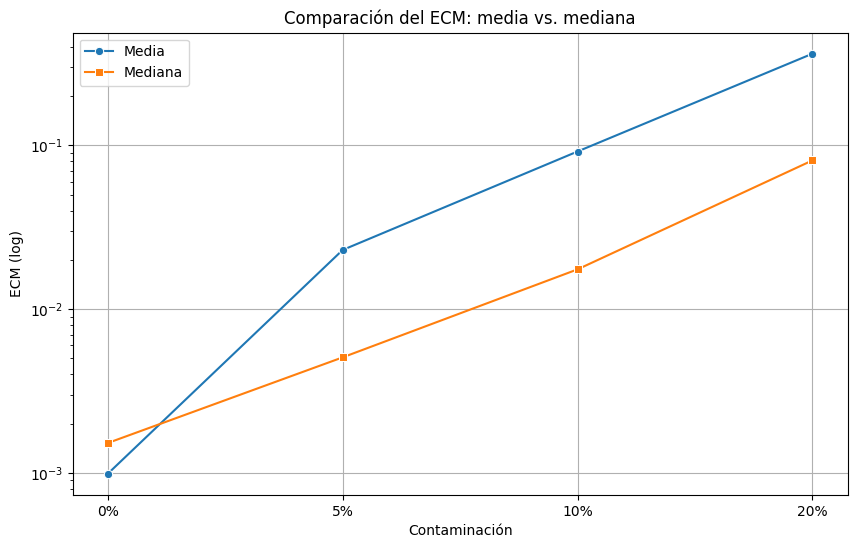

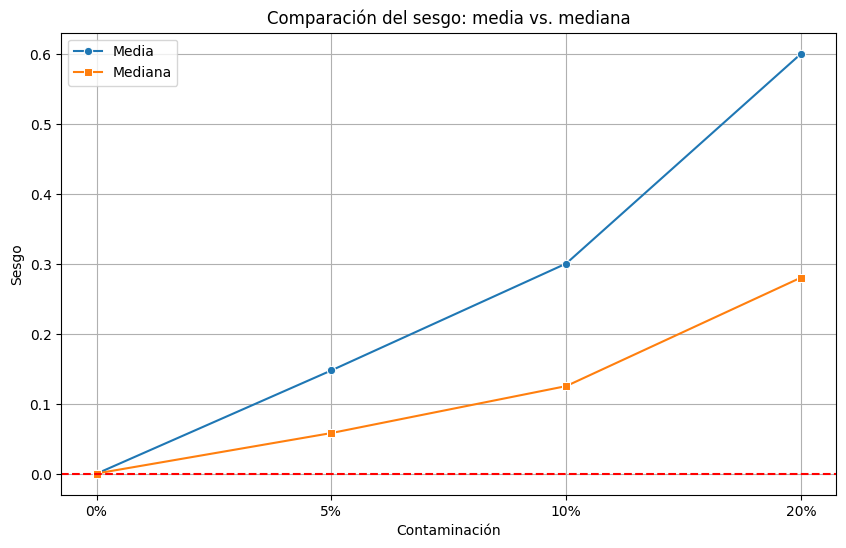

In [4]:
#Gráfico de ECM
plt.figure(figsize=(10,6))
sns.lineplot(data=df_resultados,x="Contaminación",y="ECM media",marker = 'o', label="Media")
sns.lineplot(data=df_resultados,x="Contaminación",y="ECM mediana",marker ='s', label="Mediana")
plt.yscale('log')
plt.title("Comparación del ECM: media vs. mediana")
plt.xlabel("Contaminación")
plt.ylabel("ECM (log)")
plt.grid(True)
plt.legend()
plt.show()

#Gráfico del sesgo
plt.figure(figsize=(10,6))
sns.lineplot(data=df_resultados,x="Contaminación",y="Sesgo media",marker = 'o', label="Media")
sns.lineplot(data=df_resultados,x="Contaminación",y="Sesgo mediana",marker ='s', label="Mediana")
plt.axhline(0, color='red', linestyle='--')
plt.title("Comparación del sesgo: media vs. mediana")
plt.xlabel("Contaminación")
plt.ylabel("Sesgo")
plt.grid(True)
plt.legend()
plt.show()

A partir de los resultados obtenidos en la simulaciones se observa que, cuando en las muestras existen outliers (valores atipicos), el estimador de la media es más volátil que el de la mediana.

Como se demuestra en la tabla de la primera celda de código y los gráficos siguientes, a medida que el porcentaje de contaminación de la muestra aumenta, el sesgo de la media crece más rápidamente que el de la mediana. Esto también queda claro en el gráfico comparativo del error cuadrático medio. En este caso se optó por la escala logarítmica en el eje Y para poder apreciar el punto de cruce en el que el ECM de la media supera al de la mediana (**exactamente un nivel del contaminación del 0,14%**). De no aplicar la escala logarítmica, la escala exponencial de crecimiento del ECM de la media impide comparar visualmente con la mediana.

###Explicación
Estos resultados se deben a que la media es un estimador que se obtiene sumando el valor de todas las observaciones y dividiendolo por el total. El estimador da el mismo peso a todas las observaciones de la muestra, por lo que los valores extremos afectan el valor total de la sumatoria, desplazándo notablemente el resultado. En contraposición, el estimador de la mediana es el valor central que se obtiene luego de ordenar las observaciones de la muestra. Así, los valores extremos no afectan la variabilidad del estimador, y por lo tanto tampoco el sesgo y el ECM.

In [5]:
#1.2 Regresión lineal bajo contaminación

#Definición de parámetros
M = 500
n = 100
beta_true = [5,2]
sigma_true = 1
porcentajes = [0,0.05,0.10,0.20]

#Contaminación de y
def y_contaminada(n,p,X,beta_true):
  epsilon = np.random.normal(0,1,n)
  y = X @ beta_true + epsilon

  n_outliers = int(n*p)

  idx_outliers = np.random.choice(n,n_outliers,replace=False)
  y[idx_outliers] = np.random.normal(3, sqrt(3), n_outliers)
  return y

#Estimadores
def estimador_ols(X,y):
  inv_xx = np.linalg.inv(X.T @ X)
  beta_hat = inv_xx @ X.T @ y
  return beta_hat

def funcion_obj_lad(beta,X,y):
  residuos = y - X @ beta
  return np.sum(np.abs(residuos))

def estimador_lad(X,y):
  beta_inicial = estimador_ols(X,y)
  resultado = minimize(funcion_obj_lad, beta_inicial, args=(X,y))
  return resultado.x

#Simulación
resultados_12 = []

for p in porcentajes:
  betas_ols = np.zeros((M,2))
  betas_lad = np.zeros((M,2))

  for _ in range(M):
    #Generar X
    x = np.random.uniform (0,10,n)
    X = np.column_stack((np.ones(n), x)) # Junta x con una columna de unos para el intercepto

    #Generar y
    y = y_contaminada(n,p,X,beta_true)

    #Calcular estimadores
    betas_ols[_] = estimador_ols(X,y)
    betas_lad[_] = estimador_lad(X,y)

  #Calculo de sesgo y ECM
  sesgo_ols = np.mean(betas_ols[:,1]) - beta_true[1]
  ecm_ols = np.mean((betas_ols[:,1] - beta_true[1])**2)

  sesgo_lad = np.mean(betas_lad[:,1]) - beta_true[1]
  ecm_lad = np.mean((betas_lad[:,1] - beta_true[1])**2)

  resultados_12.append({
      "Contaminación": f"{int(p*100)}%",
      "p": p,
      "Sesgo OLS": sesgo_ols,
      "ECM OLS": ecm_ols,
      "Sesgo LAD": sesgo_lad,
      "ECM LAD": ecm_lad,
      "Distribución OLS": betas_ols[:,1],
      "Distribución LAD": betas_lad[:,1]
  })

print(f"{'Contaminación':<15} | {'Sesgo OLS':<12} | {'ECM OLS':<12} | {'Sesgo LAD':<12} | {'ECM LAD':<12}")
print("-" * 75)
for res in resultados_12:
    print(f"{res['Contaminación']:<15} | "
          f"{res['Sesgo OLS']:12.4f} | "
          f"{res['ECM OLS']:12.4f} | "
          f"{res['Sesgo LAD']:12.4f} | "
          f"{res['ECM LAD']:12.4f}")

Contaminación   | Sesgo OLS    | ECM OLS      | Sesgo LAD    | ECM LAD     
---------------------------------------------------------------------------
0%              |       0.0014 |       0.0013 |       0.0010 |       0.0018
5%              |      -0.1042 |       0.0220 |      -0.0012 |       0.0022
10%             |      -0.2100 |       0.0646 |      -0.0013 |       0.0023
20%             |      -0.4089 |       0.2020 |      -0.0037 |       0.0031


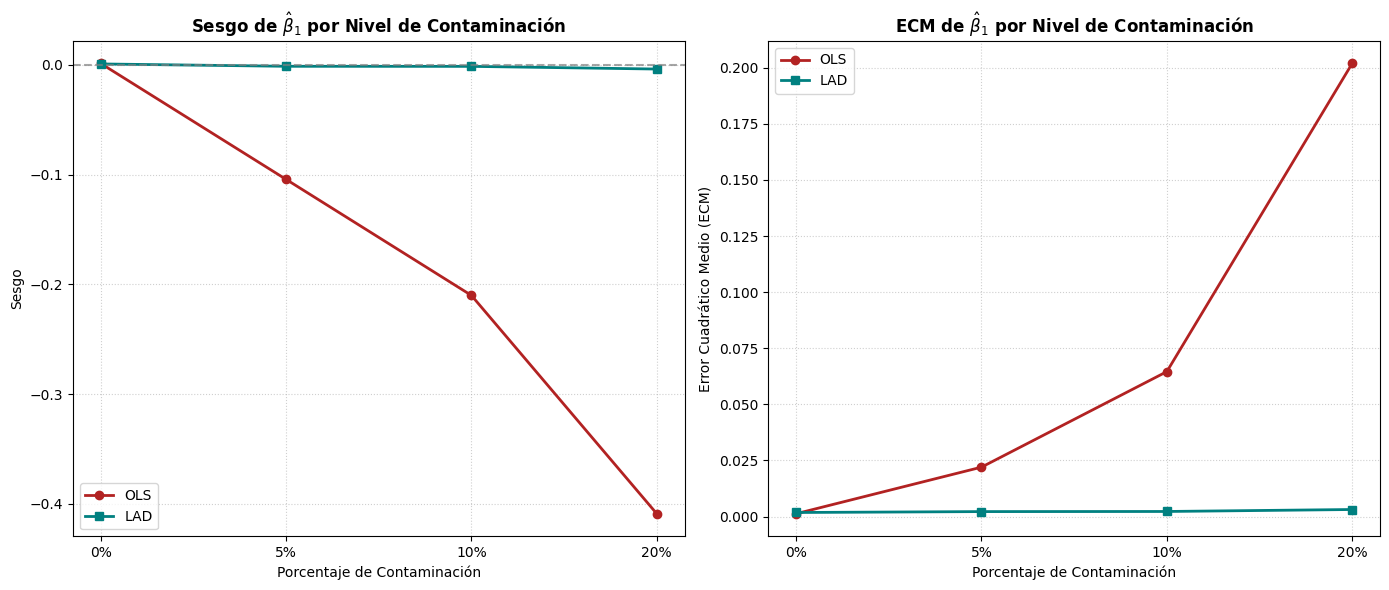

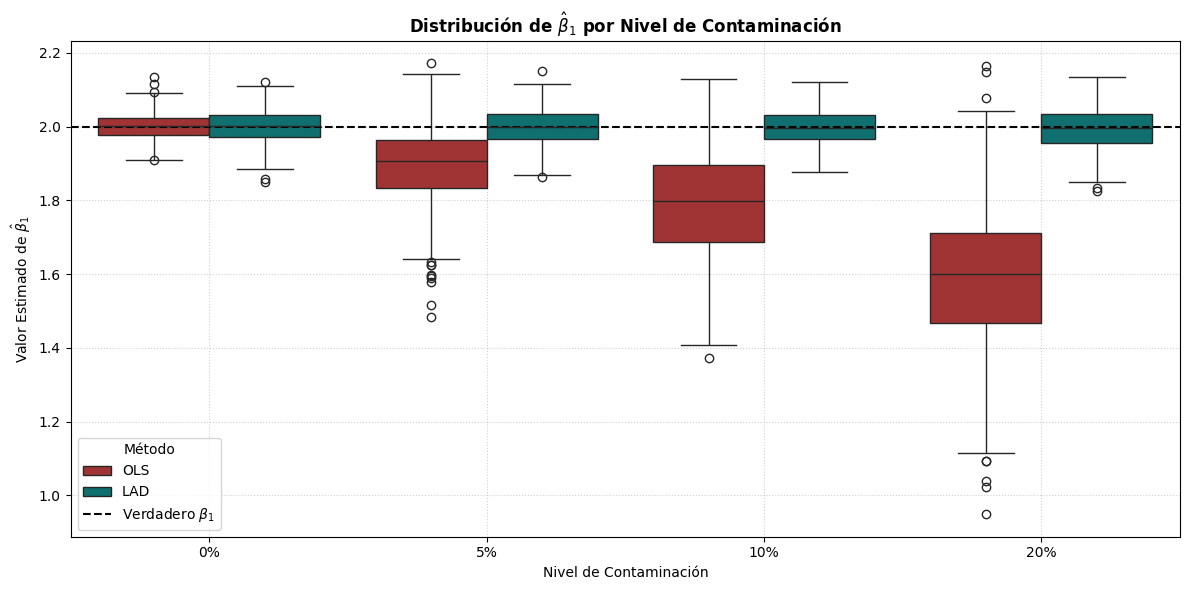

In [6]:

#Gráficos
#Sesgo y ECM según contaminación
niveles = [res['Contaminación'] for res in resultados_12]
sesgos_ols = [res['Sesgo OLS'] for res in resultados_12]
ecms_ols = [res['ECM OLS'] for res in resultados_12]
sesgos_lad = [res['Sesgo LAD'] for res in resultados_12]
ecms_lad = [res['ECM LAD'] for res in resultados_12]


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Parte Sesgo
axes[0].plot(niveles, sesgos_ols, marker='o', label='OLS', color='firebrick', linewidth=2)
axes[0].plot(niveles, sesgos_lad, marker='s', label='LAD', color='teal', linewidth=2)
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.7)
axes[0].set_title(r'Sesgo de $\hat{\beta}_1$ por Nivel de Contaminación', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Porcentaje de Contaminación', fontsize=10)
axes[0].set_ylabel('Sesgo', fontsize=10)
axes[0].legend()

# Parte de ECM
axes[0].grid(True, linestyle=':', alpha=0.6)

axes[1].plot(niveles, ecms_ols, marker='o', label='OLS', color='firebrick', linewidth=2)
axes[1].plot(niveles, ecms_lad, marker='s', label='LAD', color='teal', linewidth=2)
axes[1].set_title(r'ECM de $\hat{\beta}_1$ por Nivel de Contaminación', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Porcentaje de Contaminación', fontsize=10)
axes[1].set_ylabel('Error Cuadrático Medio (ECM)', fontsize=10)
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

#Boxplots para cada nivel de contaminación
datos_boxplot = []
for res in resultados_12:
    nivel = res['Contaminación']
    # Extraer OLS
    for val in res['Distribución OLS']:
        datos_boxplot.append({'Contaminación': nivel, 'Estimador': 'OLS', 'Valor': val})
    # Extraer LAD
    for val in res['Distribución LAD']:
        datos_boxplot.append({'Contaminación': nivel, 'Estimador': 'LAD', 'Valor': val})

df_box = pd.DataFrame(datos_boxplot)

plt.figure(figsize=(12, 6))
sns.boxplot(
    x='Contaminación',
    y='Valor',
    hue='Estimador',
    data=df_box,
    palette=['firebrick', 'teal']
)
plt.axhline(
    beta_true[1],
    color='black',
    linestyle='--',
    linewidth=1.5,
    label=f'Verdadero $\\beta_1$'
)
plt.title(f'Distribución de $\\hat{{\\beta}}_1$ por Nivel de Contaminación', fontsize=12, fontweight='bold')
plt.ylabel('Valor Estimado de $\\hat{\\beta}_1$', fontsize=10)
plt.xlabel('Nivel de Contaminación', fontsize=10)
plt.legend(title='Método')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

Los resultados obtenidos en la tabla y representados en los gráficos permiten afirmar que el método de estimación de mínimos cuadrados ordinarios presenta notablemente más sesgo y ECM que el método LAD de mínimas desviaciones absolutas ante muestras contaminadas con outliers.

Los gráficos que comparan el sesgo y el ECM de de la estimación de B1 de ambos métodos muestran cómo en el caso de OLS las medidas aumentan rápidamente, especialmente entre el 10% y el 20% de contaminación, mientras que para LAD se mantiene estabilizado en 0. A su vez, el boxplot expone la magnitud de la dispersión del estimador OLS.

###Explicación
Como en el método OLS se basa en minimizar la suma de los errores al cuadrado los valores extremo pesan mucho en el cálculo del estimador, mientras que el método LAD minimiza la suma de los valores absolutos de los residuos. Este último encuentra la mediana condicional de los datos en lugar de la media condicional, por lo que ocurre lo mismo que fue explicado en el inciso previo.


##Parte 2. Paradoja de Simpson y variables omitidas

In [7]:
#2.1
M = 1000
n = 500

n_lista = [50,200,500,1000,5000] #Para el loop que demuestra que no desaparece el sesgo
                               #al cambiar el tamaño
resultados_sesgos = []
beta_x = 0.5

#Para guardar coeficientes
resultados_2=[]

# Lista para almacenar los datos de X, Y, Z para el gráfico final
lista_X = []
lista_Y = []
lista_Z = []

for _ in range(M):
  Z=np.random.choice([1,2,3,4], size=n)
  W=np.random.choice([1,2,3,4], size=n)

  # X correlacionado con Z y W
  X = 2*Z -2*W + np.random.normal(0, 0.5, n)
  Y = 2*Z + 2*W + np.random.normal(0, 1, n)

  # Almacenar datos para el gráfico final
  lista_X.extend(X)
  lista_Y.extend(Y)
  lista_Z.extend(Z)

  #Modelos
  #Sin control
  b1=sm.OLS(Y,sm.add_constant(X)).fit().params[1]
  #Control Z
  b2=sm.OLS(Y,sm.add_constant(np.column_stack((X,Z)))).fit().params[1]
  #Control W
  b3=sm.OLS(Y,sm.add_constant(np.column_stack((X,W)))).fit().params[1]

  resultados_2.append([b1,b2,b3])

df_beta=pd.DataFrame(resultados_2,columns=["Sin control","Control Z","Control W"])

#Chequear lo que pide la consigna
resumen= pd.DataFrame({
    'medias_coeficientes': df_beta.mean(),
    'Desvio_estándar': df_beta.std(),
    'Varianza': df_beta.var()
})

print(f"{'Modelo / Estimador':<20} | {'Medias Coeficientes':<20} | {'Desvío Estándar':<18} | {'Varianza':<15}")
print("-" * 80)

for idx, row in resumen.iterrows():
    print(f"{idx:<20} | "
          f"{row['medias_coeficientes']:20.4f} | "
          f"{row['Desvio_estándar']:18.4f} | "
          f"{row['Varianza']:15.4f}")


#Sesgos según tamaño

for n_val in n_lista:
  b1_lista = []
  b2_lista = []
  b3_lista = []

  for _ in range(M):
    Z_n=np.random.choice([1,2,3,4], size=n)
    W_n=np.random.choice([1,2,3,4], size=n)

    # X correlacionado con Z y W
    X_n = 2*Z -2*W + np.random.normal(0, 0.5, n)
    Y_n = 2*Z + 2*W + np.random.normal(0, 1, n)

    b1_lista.append(sm.OLS(Y_n, sm.add_constant(X_n)).fit().params[1])
    b2_lista.append(sm.OLS(Y_n, sm.add_constant(np.column_stack((X_n, Z_n)))).fit().params[1])
    b3_lista.append(sm.OLS(Y_n, sm.add_constant(np.column_stack((X_n, W_n)))).fit().params[1])

  sesgo_sin_control = np.mean(b1_lista) - beta_x

  resultados_sesgos.append({
      "Tamaño": n_val,
      "Sesgo Sin Control": sesgo_sin_control,
  })

print("\n\n")

print(f" Evolución del sesgo con distintos tamaños de muestra")
print(f"{'Tamaño':<15} | {'Sesgo Sin Control':<12}")
print("-" * 75)
for res in resultados_sesgos:
    print(f"{res['Tamaño']:<15} | "
          f"{res['Sesgo Sin Control']:12.4f} | ")



Modelo / Estimador   | Medias Coeficientes  | Desvío Estándar    | Varianza       
--------------------------------------------------------------------------------
Sin control          |              -0.0010 |             0.0296 |          0.0009
Control Z            |              -0.9528 |             0.0214 |          0.0005
Control W            |               0.9516 |             0.0216 |          0.0005



 Evolución del sesgo con distintos tamaños de muestra
Tamaño          | Sesgo Sin Control
---------------------------------------------------------------------------
50              |      -0.4719 | 
200             |      -0.4714 | 
500             |      -0.4714 | 
1000            |      -0.4715 | 
5000            |      -0.4721 | 


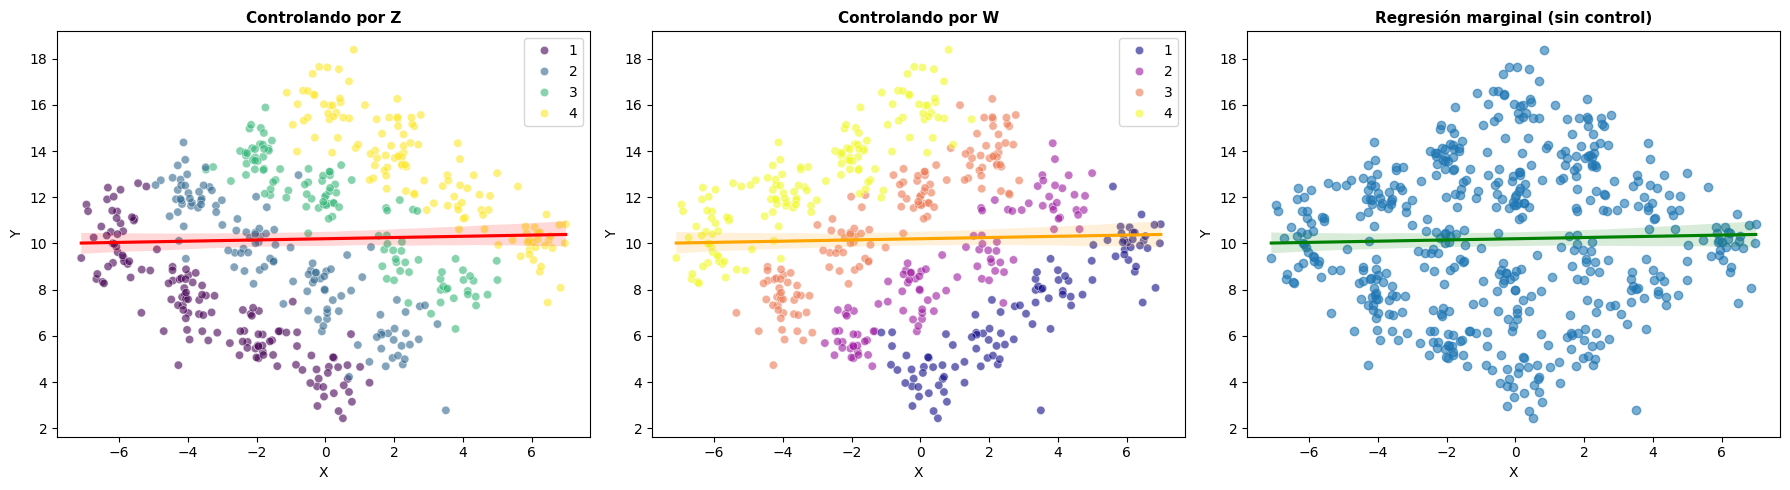

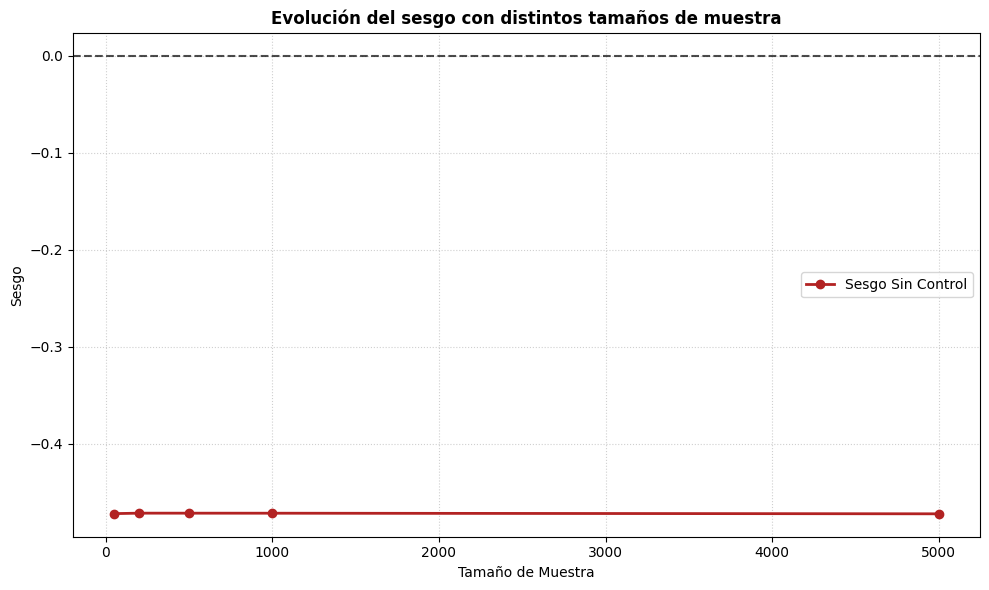

In [8]:
#2.2
#Gráfico que demuestra la paradoja
fig, axes = plt.subplots(1,3,figsize=(18,5))

#Condicionando por Z
sns.scatterplot(x=X, y=Y, hue=Z, palette='viridis', alpha=0.6, ax=axes[0], legend='full')
sns.regplot(x=X, y=Y, scatter=False, color='red', ax=axes[0])
axes[0].set_title("Controlando por Z", fontsize=11, fontweight='bold')
axes[0].set_xlabel("X", fontsize=10)
axes[0].set_ylabel("Y", fontsize=10)

#Condicionando por W
sns.scatterplot(x=X, y=Y, hue=W, palette='plasma', alpha=0.6, ax=axes[1], legend='full')
sns.regplot(x=X, y=Y, scatter=False, color='orange', ax=axes[1])
axes[1].set_title("Controlando por W", fontsize=11, fontweight='bold')
axes[1].set_xlabel("X", fontsize=10)
axes[1].set_ylabel("Y", fontsize=10)

#Regresión sin control
axes[2].scatter(X, Y, alpha=0.6)
sns.regplot(x=X, y=Y, scatter=False, color='green', ax=axes[2])
axes[2].set_title("Regresión marginal (sin control)", fontsize=11, fontweight='bold')
axes[2].set_xlabel("X", fontsize=10)
axes[2].set_ylabel("Y", fontsize=10)

plt.tight_layout()
plt.show()

#Gráfico sesgo
#Datos
ns=[res['Tamaño'] for res in resultados_sesgos]
sesgos_sin_control=[res['Sesgo Sin Control'] for res in resultados_sesgos]

plt.figure(figsize=(10,6))
plt.plot(ns, sesgos_sin_control, marker='o', label='Sesgo Sin Control', color='firebrick', linewidth=2)
plt.axhline(0, color='black', linestyle='--', alpha=0.7)
plt.title(r'Evolución del sesgo con distintos tamaños de muestra', fontsize=12, fontweight='bold')
plt.xlabel('Tamaño de Muestra', fontsize=10)
plt.ylabel('Sesgo', fontsize=10)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

**La paradoja de Simpson es un fenómeno estadístico en el cual una tendencia o relación observada en diferentes grupos individuales se invierte o desaparece cuando esos grupos se combinan en un único análisis agregado.** El fenómeno ocurre por una variable omitida que está correlacionada tanto con la variable dependiente como con la independiente.

Justamentente, al tratarse de un problema de variable omitida al estimar la regresión sin control el sesgo que aparece en la estimación de B1 no desaparece al aumentar el tamaño de la muestra. Esto puede observarse en el gráfico inferior, en el que el sesgo está representado por la línea recta que se mantiene en un valor de -0,47 incluso al aumentar el tamaño de la muestra a 5000 individuos.

Por otra parte, los primeros tres gráficos muestran explícitamente la paradoja de Simpson: en la primera y segunda imágen se observan los datos descompuestos en subgrupos identificados por colores en función de la variable $Z$ (pendiente negativa) y $W$ (pendiente positiva) respectivamente mientras que encima se ve la recta de regresión correpondiente al modelo sin control. De esta manera queda claro cómo la regresión de Y sobre X devuelve una recta que no se condice con los subgrupos observados.

Por último, en el tercer gráfico puede verse cómo todos los puntos de datos aparecen de un solo color y se ajusta una única línea de regresión. Al no considerar las agrupaciones o variables de confusión, la pendiente de la línea es prácticamente horizontal. A nivel agregado, parecería que la variable $X$ no tiene ningún efecto sobre $Y$

##Parte 3. Análisis empírico con Gapminder

In [9]:
#Ejercicio 3. Parte A

# Carga de Gapminder desde URL publica
url_gap = 'https://raw.githubusercontent.com/lucianobunino/Trabajo_Pr-ctico_R/refs/heads/main/gapminder.csv'
gap = pd.read_csv(url_gap)

#Visualización de paises aparecen
paises_disponibles = sorted(gap['country'].unique())
print(paises_disponibles)

#Visualización de datos de mi país
china = gap[gap['country'] == 'China']
print(china)


['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Brunei', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde', 'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', 'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cuba', 'Cyprus', 'Czech Republic', 'Denmark', 'Djibouti', 'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia', 'Eswatini', 'Ethiopia', 'Fiji', 'Finland', 'France', 'Gabon', 'Gambia', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Grenada', 'Guatemala', 'Guinea', 'Guinea-Bissau', 'Guyana', 'Haiti', 'Honduras', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Iran', 'Iraq', 'Ireland', 'Israel', 

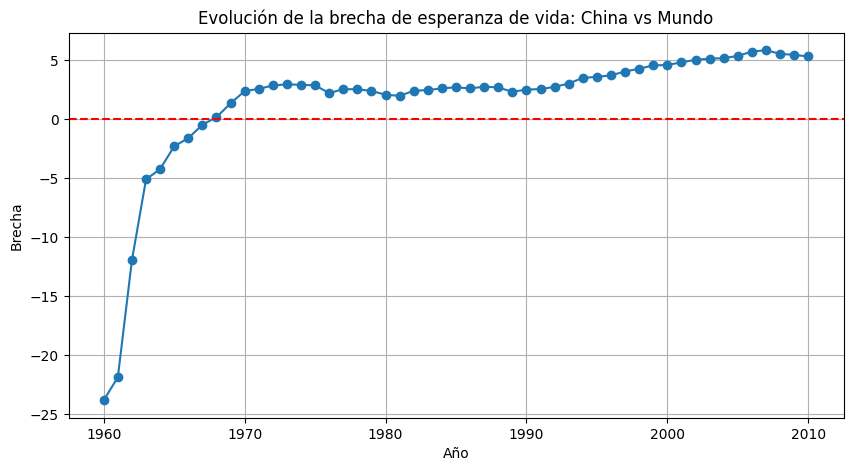

In [10]:
#Convergencia
mi_pais="China"

#Promedio mundial por año
promedio_mundial=gap.groupby('year')['life_expectancy'].mean().reset_index()
promedio_mundial.columns=['year','mundo_lifeexp']

#Filtro datos de mi pais
datos_pais=gap[gap['country'] == mi_pais][['year','life_expectancy']]
datos_pais.columns=['year','pais_lifeexp']

#Unir para comparar
df_comparativo=pd.merge(promedio_mundial,datos_pais,on='year')

#Calcular la brecha
df_comparativo['brecha']=df_comparativo['pais_lifeexp']-df_comparativo['mundo_lifeexp']

#Gráfico
plt.figure(figsize=(10, 5))
plt.plot(df_comparativo['year'], df_comparativo['brecha'], marker='o', linestyle='-')
plt.axhline(0, color='red', linestyle='--')
plt.title(f"Evolución de la brecha de esperanza de vida: {mi_pais} vs Mundo")
plt.xlabel("Año")
plt.ylabel("Brecha")
plt.grid(True)
plt.show()

###Análisis de convergencia
La base de datos Gapminder contiene datos del país elegido, **China**, a partir de 1960. En los años analizados se observa que la brecha en la esperanza de vida con el promedio mundial era muy marcada (de hasta casi 25 años a 5 por debajo del promedio) entre 1960 y  1963. A partir de ese momento la brecha se redujo rápidamente, en 1968 esta se cerró y luego pasó a ser positiva. En 2010 la esperanza de vida en China superó por 5 años a la del promedio mundial.

De esta forma, si bien se redujo la magnitud de la brecha entre China y el resto del mundo, esta no desapareció. Así no puede decirse propiamente que la esperanza de vida en China convergió a la del promedio mundial.

In [11]:
#Atipicidad

#Chequeo de las regiones de la base
print(gap['world_region'].unique())

#Defino los continentes
continentes = {
  'south_asia':'Asia',
  'sub_saharan_africa':'Africa',
  'europe_central_asia':'Asia',
  'middle_east_north_africa':'Africa',
  'america':'America',
  'east_asia_pacific':'Asia'

}

#Creo la columna en la base
gap['continent'] = gap['world_region'].map(continentes)

print(gap[gap['continent'].isna()]['continent'].unique())

['south_asia' 'sub_saharan_africa' 'europe_central_asia'
 'middle_east_north_africa' 'america' 'east_asia_pacific']
[]


El periodo de mayor anomalía fue: 1960 a 1965
Duración: 6 años
Magnitud máxima de desviación: 29.12 años


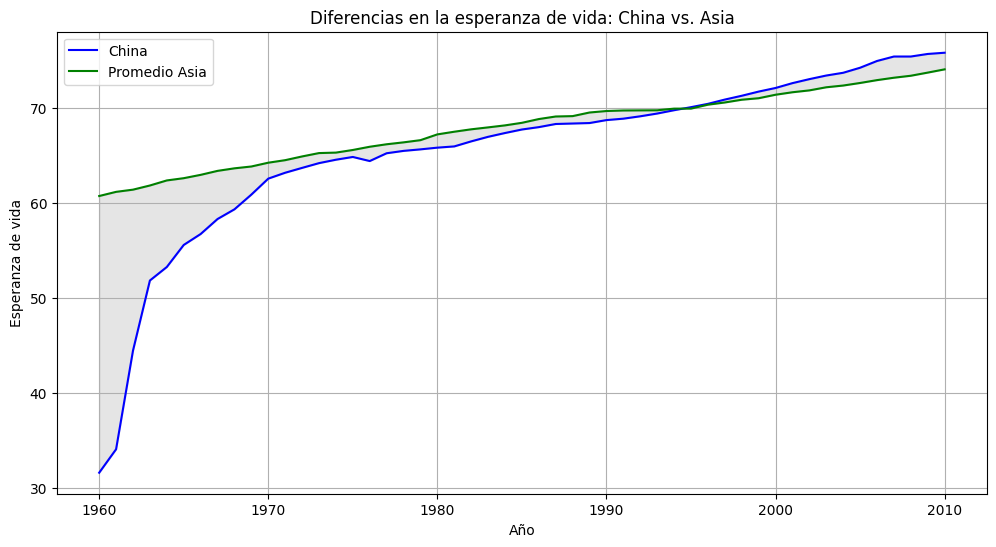

In [12]:
mi_continente = "Asia"

#Calculo el promedio del continente por año excluyendo el efecto de China
gap_sin_pais=gap[(gap['continent']==mi_continente) & (gap['country'] != mi_pais)]
promedio_continente = gap_sin_pais.groupby('year')['life_expectancy'].mean().reset_index()
promedio_continente.columns = ['year', 'continente_lifeexp']

#Filtro el pais
datos_pais = gap[gap['country'] == mi_pais][['year', 'life_expectancy']]
datos_pais.columns = ['year', 'pais_lifeexp']

#Calculo la desviacion
df_analisis = pd.merge(datos_pais, promedio_continente, on='year')
df_analisis['desviacion'] = df_analisis['pais_lifeexp'] - df_analisis['continente_lifeexp']

#Defino anomalias
umbral = df_analisis['desviacion'].std()
df_analisis['es_anomalia'] = df_analisis['desviacion'].abs() > umbral

df_analisis['grupo_id'] = (df_analisis['es_anomalia'] != df_analisis['es_anomalia'].shift()).cumsum()

df_anomalias = df_analisis[df_analisis['es_anomalia'] == True].copy()

if not df_anomalias.empty:
    periodos = df_anomalias.groupby('grupo_id').agg({
        'year': ['min', 'max', 'count'],
        'desviacion': lambda x: x.abs().max()
    })

    periodos.columns = ['Año_inicio', 'Año_fin', 'Duración', 'Magnitud_max']

    #Periodo de anomalía con mayor duración
    periodo_max = periodos.loc[periodos['Duración'].idxmax()]

    print(f"El periodo de mayor anomalía fue: {int(periodo_max['Año_inicio'])} a {int(periodo_max['Año_fin'])}")
    print(f"Duración: {int(periodo_max['Duración'])} años")
    print(f"Magnitud máxima de desviación: {periodo_max['Magnitud_max']:.2f} años")
else:
    print("No se encontraron anomalías.")

    #Gráfico
if df_analisis.empty:
  print("El DataFrame está vacío, no se puede graficar.")
else:
    plt.figure(figsize=(12,6))

    plt.plot(df_analisis['year'], df_analisis['pais_lifeexp'], label='China', linestyle='-', color='blue')
    plt.plot(df_analisis['year'], df_analisis['continente_lifeexp'], label='Promedio Asia', linestyle='-', color='green')
    plt.fill_between(df_analisis['year'],
                 df_analisis['pais_lifeexp'],
                 df_analisis['continente_lifeexp'],
                 color='gray', alpha=0.2)
    plt.title("Diferencias en la esperanza de vida: China vs. Asia")
    plt.xlabel("Año")
    plt.ylabel("Esperanza de vida")
    plt.grid(True)
    plt.legend()
    plt.show()

##Análisis de atipicidad
Para determinar durante qué periodos la esperanza de vida en China tuvo un desarrollo atípico respecto del promedio de Asia se utilizó como criterio que **la esperanza de vida en dicho país se alejara al menos un desvío estándar de la esperanza del continente**.

De esta manera, se encontró que el periodo de mayor anomalía duró 6 años, entre 1960 y 1965, y su magnitud máxima fue una diferencia negativa de 29,12 años respecto del promedio del continente. Al indagar qué motivaba esta gran diferencia se encontró que el gobierno, bajo el liderazgo de Mao Zedong, entre 1959 y 1962 aplicó una política denominada *"El Gran Salto Adelante"*. Bajo este esquema se pretendía transformar rápidamente la economía agrícola china en una potencia industrial.

Como consecuencia de la mala planificación y mala asignación de recursos de parte del gobierno, la destrucción de la agricultura, el mal clima y la represión a aquellos que cuestionaban las politicas, la economía china desembocó en un proceso llamado *"La Gran Hambruna"*. De esta manera, durante 1959 y 1961 murieron por inanición y enfermedades asociadas entre 15 y 45 millones de personas. A pesar de que el peor momento de la crisis ocurrió entre estos años la recuperación en la salud de la población se retrasó hasta mediados y fines de la década, momento a partir del cual se observa cómo la brecha prácticamente se cerró.